# 📊 Bölüm 1: Temel İstatistik
## Olist E-Ticaret Verisiyle İstatistiğe Giriş

Bu notebook'ta şu konuları ele alacağız:

| Konu | Açıklama |
|------|----------|
| Tanımlayıcı İstatistik | Veriyi sayılarla özetleme |
| Merkezi Eğilim Ölçüleri | Ortalama, medyan, mod |
| Yayılım Ölçüleri | Standart sapma, varyans, IQR |
| Frekans Dağılımları | Histogramlar ve yoğunluk grafikleri |
| Kutu Grafikleri | Boxplot ile aykırı değer tespiti |
| Normallik | Normal dağılıma giriş ve görselleştirme |

> **Dataset:** Brezilya'nın en büyük e-ticaret platformu Olist'in 2016-2018 yılları arasındaki 100.000+ siparişi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


## 1. Veri Yükleme ve İlk Bakış

In [2]:
# Veri setlerini yükle
orders       = pd.read_csv('../data/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
order_items  = pd.read_csv('../data/olist_order_items_dataset.csv')
payments     = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews      = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers    = pd.read_csv('../data/olist_customers_dataset.csv')
products     = pd.read_csv('../data/olist_products_dataset.csv')
translation  = pd.read_csv('../data/product_category_name_translation.csv')

# Temel birleştirme
df = (orders
      .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
      .merge(reviews[['order_id','review_score']].drop_duplicates('order_id'), on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left'))

# Teslimat süresi (gün)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

print(f'Satır: {len(df):,}  |  Sütun: {df.shape[1]}')
df.head(3)

Satır: 99,440  |  Sütun: 12


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,review_score,customer_state,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,4.0,SP,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,4.0,BA,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,5.0,GO,9.0


## 2. Tanımlayıcı İstatistik

Tanımlayıcı (betimleyici) istatistik, veri kümesini sayısal özetlerle ifade etmemizi sağlar.
Bunlar: merkezi eğilim, yayılım ve şekil ölçüleridir.

In [3]:
num_cols = ['payment_value', 'review_score', 'delivery_days']
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
desc.style.format('{:.2f}').background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
payment_value,99440.00,160.99,221.95,0.00,62.01,105.29,176.97,13664.08,9.15,233.41
review_score,98672.00,4.09,1.35,1.00,4.00,5.00,5.00,5.00,-1.37,0.51
delivery_days,96475.00,12.09,9.55,0.00,6.00,10.00,15.00,209.00,3.83,39.28


### Neden bu sayılar önemli?

- **mean (ortalama):** Tüm değerlerin toplamı / sayısı. Aykırı değerlere duyarlıdır.
- **50% (medyan):** Sıralanmış verinin tam ortasındaki değer. Aykırı değerlere dayanıklıdır.
- **std (standart sapma):** Değerlerin ortalamadan ortalama uzaklığı.
- **skewness (çarpıklık):** >0 sağa çarpık, <0 sola çarpık dağılım.
- **kurtosis (basıklık):** >3 sivri, <3 yayvan dağılım.

## 3. Merkezi Eğilim Ölçüleri

Ortalama, medyan ve mod — veriyi tek bir sayıyla temsil etmenin üç farklı yolu.

=== Ödeme Tutarı (BRL) ===
  Ortalama  :     160.99 BRL
  Medyan    :     105.29 BRL
  Mod       :      77.57 BRL
  Fark (Ort-Med):   55.70 BRL  → aykırı değer baskısı


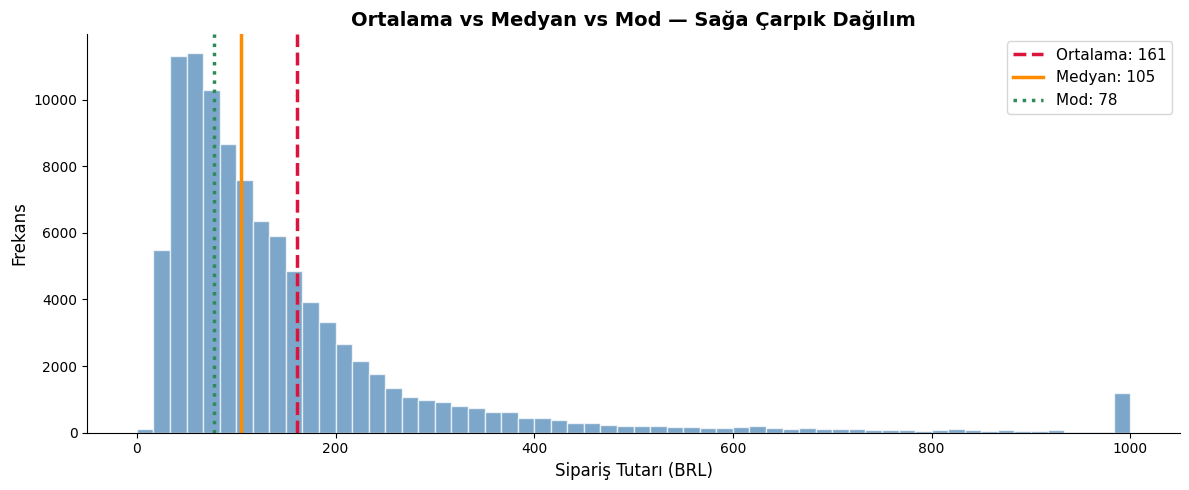


💡 Sağa çarpık dağılımlarda Ortalama > Medyan > Mod sıralaması görülür.


In [4]:
price_data = df['payment_value'].dropna()

mean_val   = price_data.mean()
median_val = price_data.median()
mode_val   = price_data.mode()[0]

print('=== Ödeme Tutarı (BRL) ===')
print(f'  Ortalama  : {mean_val:>10.2f} BRL')
print(f'  Medyan    : {median_val:>10.2f} BRL')
print(f'  Mod       : {mode_val:>10.2f} BRL')
print(f'  Fark (Ort-Med): {mean_val - median_val:>7.2f} BRL  → aykırı değer baskısı')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(price_data.clip(upper=1000), bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(mean_val,   color='crimson',    lw=2.5, ls='--', label=f'Ortalama: {mean_val:.0f}')
ax.axvline(median_val, color='darkorange',  lw=2.5, ls='-',  label=f'Medyan: {median_val:.0f}')
ax.axvline(mode_val,   color='seagreen',    lw=2.5, ls=':',  label=f'Mod: {mode_val:.0f}')
ax.set_xlabel('Sipariş Tutarı (BRL)', fontsize=12)
ax.set_ylabel('Frekans', fontsize=12)
ax.set_title('Ortalama vs Medyan vs Mod — Sağa Çarpık Dağılım', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../images/01_central_tendency.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Sağa çarpık dağılımlarda Ortalama > Medyan > Mod sıralaması görülür.')

## 4. Yayılım (Dağılım) Ölçüleri

Verinin ne kadar geniş bir aralığa yayıldığını ölçer.

In [5]:
data = df['payment_value'].dropna()

variance = data.var()
std_dev  = data.std()
q1, q3   = data.quantile(0.25), data.quantile(0.75)
iqr      = q3 - q1
cv       = (std_dev / data.mean()) * 100  # Değişim katsayısı

print('=== Yayılım Ölçüleri ===')
print(f'  Varyans (σ²)              : {variance:>10.2f}')
print(f'  Standart Sapma (σ)        : {std_dev:>10.2f} BRL')
print(f'  Q1 (25. yüzdelik)         : {q1:>10.2f} BRL')
print(f'  Q3 (75. yüzdelik)         : {q3:>10.2f} BRL')
print(f'  IQR (Çeyrekler Arası)     : {iqr:>10.2f} BRL')
print(f'  Değişim Katsayısı (CV)    : {cv:>10.1f}%')
print()

# 68-95-99.7 Kuralı
mean = data.mean()
r1 = ((data >= mean - std_dev) & (data <= mean + std_dev)).mean() * 100
r2 = ((data >= mean - 2*std_dev) & (data <= mean + 2*std_dev)).mean() * 100
r3 = ((data >= mean - 3*std_dev) & (data <= mean + 3*std_dev)).mean() * 100
print('=== 68-95-99.7 Kuralı (Ampirik Kural) ===')
print(f'  μ ± 1σ içinde: {r1:.1f}%  (teorik: 68.3%)')
print(f'  μ ± 2σ içinde: {r2:.1f}%  (teorik: 95.4%)')
print(f'  μ ± 3σ içinde: {r3:.1f}%  (teorik: 99.7%)')

=== Yayılım Ölçüleri ===
  Varyans (σ²)              :   49262.36
  Standart Sapma (σ)        :     221.95 BRL
  Q1 (25. yüzdelik)         :      62.01 BRL
  Q3 (75. yüzdelik)         :     176.97 BRL
  IQR (Çeyrekler Arası)     :     114.96 BRL
  Değişim Katsayısı (CV)    :      137.9%

=== 68-95-99.7 Kuralı (Ampirik Kural) ===
  μ ± 1σ içinde: 93.4%  (teorik: 68.3%)
  μ ± 2σ içinde: 96.8%  (teorik: 95.4%)
  μ ± 3σ içinde: 98.3%  (teorik: 99.7%)


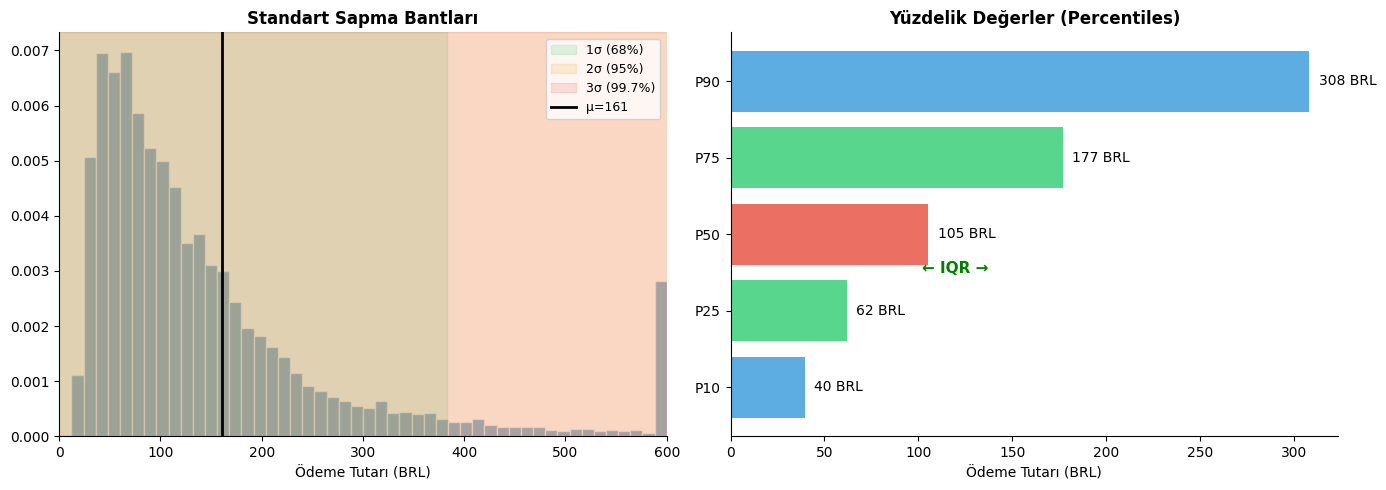

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Standart sapma görselleştirmesi
ax = axes[0]
clipped = data.clip(upper=600)
ax.hist(clipped, bins=50, color='steelblue', alpha=0.6, density=True, edgecolor='white')
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for i, (c, lbl) in enumerate(zip(colors, ['1σ (68%)', '2σ (95%)', '3σ (99.7%)'])):
    ax.axvspan(mean-(i+1)*std_dev, mean+(i+1)*std_dev, alpha=0.15, color=c, label=lbl)
ax.axvline(mean, color='black', lw=2, label=f'μ={mean:.0f}')
ax.set_xlim(0, 600)
ax.set_title('Standart Sapma Bantları', fontsize=12, fontweight='bold')
ax.set_xlabel('Ödeme Tutarı (BRL)')
ax.legend(fontsize=9)

# Sağ: IQR ve yüzdelikler
ax = axes[1]
percentiles = [10, 25, 50, 75, 90]
values = [data.quantile(p/100) for p in percentiles]
bars = ax.barh([f'P{p}' for p in percentiles], values, color=['#3498db','#2ecc71','#e74c3c','#2ecc71','#3498db'], alpha=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} BRL', va='center', fontsize=10)
ax.set_title('Yüzdelik Değerler (Percentiles)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ödeme Tutarı (BRL)')
ax.annotate('← IQR →', xy=(q1 + iqr/2, 1.5), fontsize=11, ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/01_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Frekans Dağılımları ve Histogramlar

Histogram, sayısal veriyi gruplara (bin) bölerek her grubun frekansını gösterir.

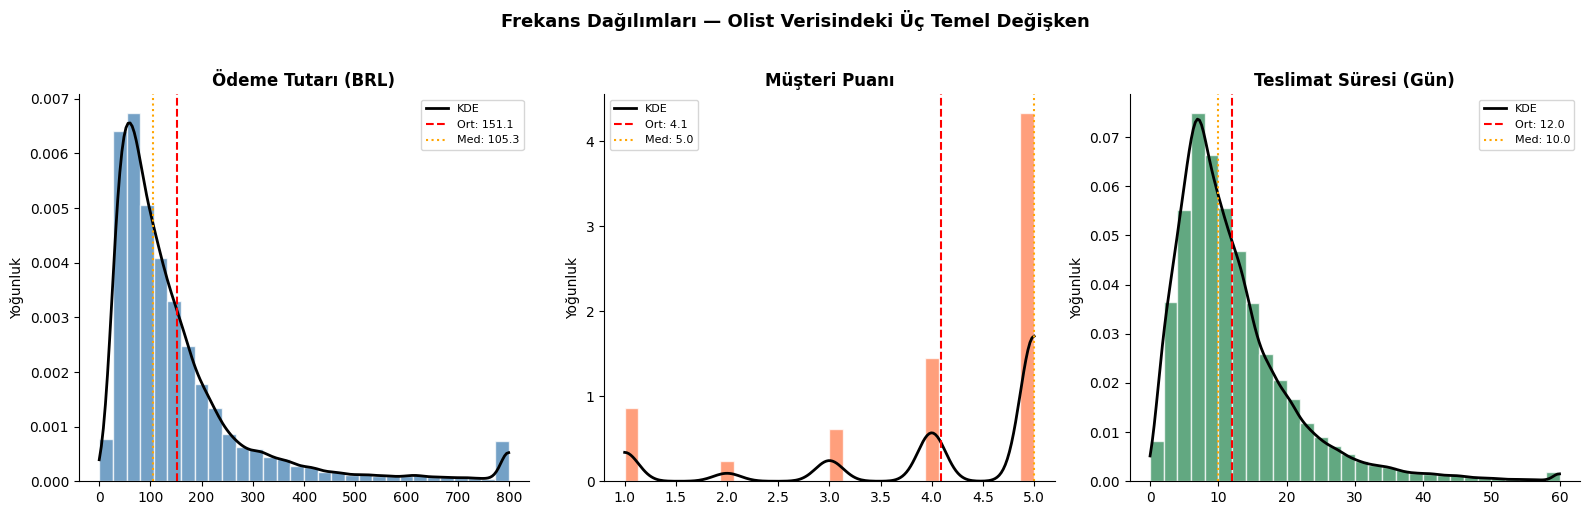

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = [
    (df['payment_value'].clip(upper=800),  'Ödeme Tutarı (BRL)',     'steelblue'),
    (df['review_score'].dropna(),           'Müşteri Puanı',          'coral'),
    (df['delivery_days'].clip(0,60),        'Teslimat Süresi (Gün)',  'seagreen'),
]

for ax, (data_col, title, color) in zip(axes, variables):
    n, bins, _ = ax.hist(data_col.dropna(), bins=30, color=color, alpha=0.75, edgecolor='white', density=True)
    # KDE eğrisi
    kde_x = np.linspace(data_col.min(), data_col.max(), 200)
    kde = stats.gaussian_kde(data_col.dropna())
    ax.plot(kde_x, kde(kde_x), color='black', lw=2, label='KDE')
    ax.axvline(data_col.mean(),   color='red',    lw=1.5, ls='--', label=f'Ort: {data_col.mean():.1f}')
    ax.axvline(data_col.median(), color='orange', lw=1.5, ls=':',  label=f'Med: {data_col.median():.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Yoğunluk')
    ax.legend(fontsize=8)

plt.suptitle('Frekans Dağılımları — Olist Verisindeki Üç Temel Değişken', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/01_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Kutu Grafiği (Boxplot) ve Aykırı Değerler

Boxplot tek bir grafikte minimum, Q1, medyan, Q3 ve maksimumu gösterir.  
IQR'nin 1.5 katını aşan değerler **aykırı değer (outlier)** sayılır.

C:\Users\SUALP\AppData\Local\Temp\ipykernel_11340\771823964.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_data, x='customer_state', y='payment_value', order=state_order,
C:\Users\SUALP\AppData\Local\Temp\ipykernel_11340\771823964.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=box_data, x='customer_state', y='payment_value', order=state_order,


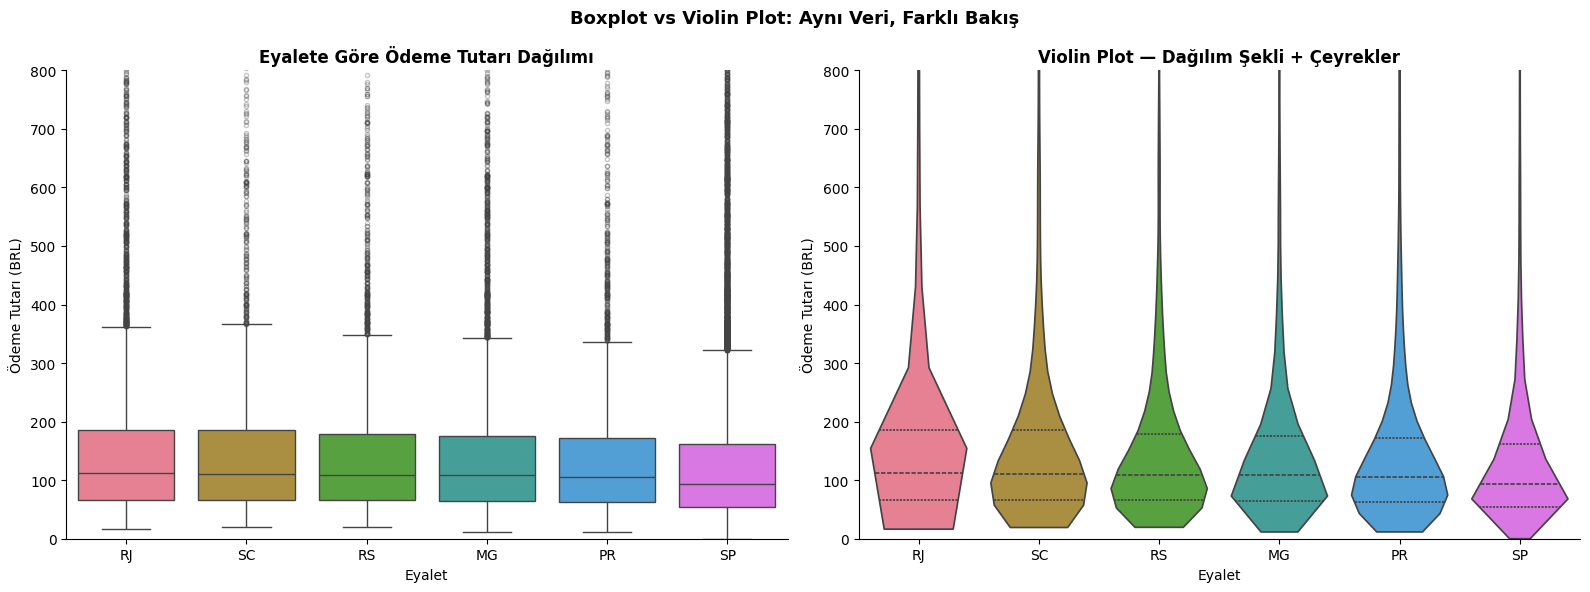

In [8]:
# Bölgesel ödeme tutarlarını karşılaştır
top_states = df['customer_state'].value_counts().head(6).index
box_data = df[df['customer_state'].isin(top_states)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
ax = axes[0]
state_order = box_data.groupby('customer_state')['payment_value'].median().sort_values(ascending=False).index
sns.boxplot(data=box_data, x='customer_state', y='payment_value', order=state_order,
            palette='husl', ax=ax, showfliers=True, flierprops=dict(marker='o', alpha=0.3, markersize=3))
ax.set_ylim(0, 800)
ax.set_title('Eyalete Göre Ödeme Tutarı Dağılımı', fontsize=12, fontweight='bold')
ax.set_xlabel('Eyalet')
ax.set_ylabel('Ödeme Tutarı (BRL)')

# Violin plot — dağılım şeklini de gösterir
ax = axes[1]
sns.violinplot(data=box_data, x='customer_state', y='payment_value', order=state_order,
               palette='husl', ax=ax, inner='quartile', cut=0)
ax.set_ylim(0, 800)
ax.set_title('Violin Plot — Dağılım Şekli + Çeyrekler', fontsize=12, fontweight='bold')
ax.set_xlabel('Eyalet')
ax.set_ylabel('Ödeme Tutarı (BRL)')

plt.suptitle('Boxplot vs Violin Plot: Aynı Veri, Farklı Bakış', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/01_boxplot_violin.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Aykırı değer analizi — IQR yöntemi
col = df['payment_value'].dropna()
Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = col[(col < lower) | (col > upper)]
pct = len(outliers) / len(col) * 100

print('=== IQR Yöntemi ile Aykırı Değer Tespiti ===')
print(f'  Alt sınır  : {lower:.2f} BRL')
print(f'  Üst sınır  : {upper:.2f} BRL')
print(f'  Aykırı değer sayısı : {len(outliers):,}')
print(f'  Toplam veri : {len(col):,}')
print(f'  Aykırı oran : %{pct:.2f}')

=== IQR Yöntemi ile Aykırı Değer Tespiti ===
  Alt sınır  : -110.43 BRL
  Üst sınır  : 349.41 BRL
  Aykırı değer sayısı : 7,866
  Toplam veri : 99,440
  Aykırı oran : %7.91


## 7. Normal Dağılım ve Çarpıklık

Normal dağılım, istatistiğin temel taşı. Pek çok test bu varsayıma dayanır.

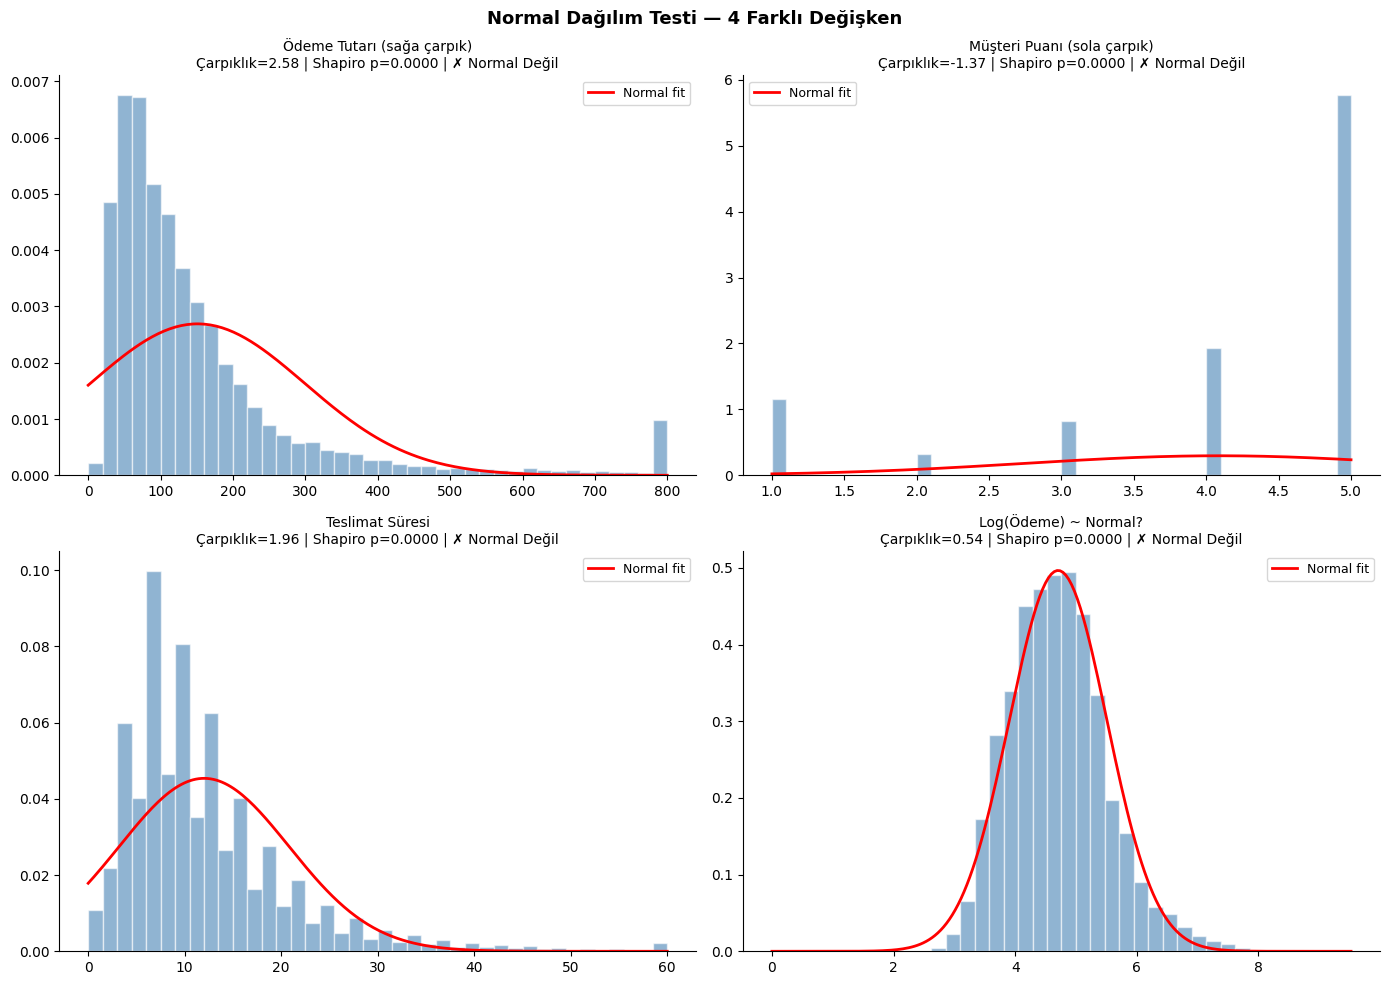

💡 Log dönüşümü sağa çarpık verileri normalleştirmek için kullanılır.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    ('Ödeme Tutarı (sağa çarpık)',  df['payment_value'].clip(upper=800).dropna()),
    ('Müşteri Puanı (sola çarpık)', df['review_score'].dropna()),
    ('Teslimat Süresi',             df['delivery_days'].clip(0, 60).dropna()),
    ('Log(Ödeme) ~ Normal?',        np.log1p(df['payment_value'].dropna())),
]

for ax, (title, data_col) in zip(axes.flat, datasets):
    # Histogram + Normal fit
    ax.hist(data_col, bins=40, color='steelblue', alpha=0.6, density=True, edgecolor='white')
    mu, sigma = data_col.mean(), data_col.std()
    x = np.linspace(data_col.min(), data_col.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal fit')

    stat, p = stats.shapiro(data_col.sample(min(5000, len(data_col)), random_state=42))
    normal_text = '✓ Normal' if p > 0.05 else '✗ Normal Değil'
    skw = data_col.skew()
    ax.set_title(f'{title}\nÇarpıklık={skw:.2f} | Shapiro p={p:.4f} | {normal_text}', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Normal Dağılım Testi — 4 Farklı Değişken', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/01_normality.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Log dönüşümü sağa çarpık verileri normalleştirmek için kullanılır.')

## 8. Q-Q Plot: Normalliği Görsel Olarak Test Et

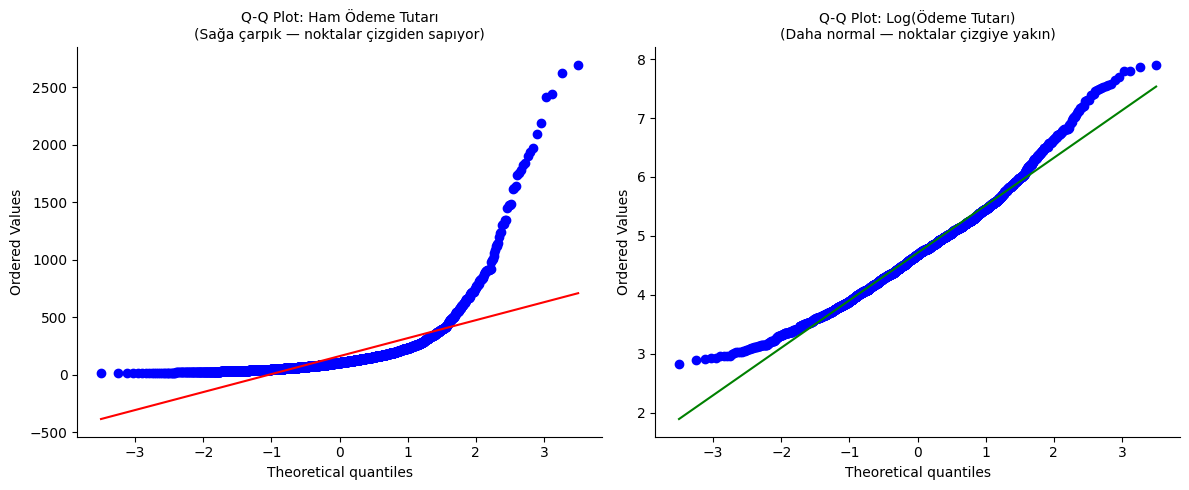

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ham veri
ax = axes[0]
sample = df['payment_value'].dropna().sample(3000, random_state=42)
stats.probplot(sample, dist='norm', plot=ax)
ax.set_title('Q-Q Plot: Ham Ödeme Tutarı\n(Sağa çarpık — noktalar çizgiden sapıyor)', fontsize=10)
ax.get_lines()[1].set_color('red')

# Log dönüşümlü
ax = axes[1]
sample_log = np.log1p(sample)
stats.probplot(sample_log, dist='norm', plot=ax)
ax.set_title('Q-Q Plot: Log(Ödeme Tutarı)\n(Daha normal — noktalar çizgiye yakın)', fontsize=10)
ax.get_lines()[1].set_color('green')

plt.tight_layout()
plt.savefig('../images/01_qqplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Özet: Temel İstatistikle Ne Öğrendik?

| Bulgu | Detay |
|-------|-------|
| Ortalama sipariş tutarı | ~154 BRL, medyan ~108 BRL (sağa çarpık) |
| Müşteri puanı | Büyük çoğunluk 5 puan veriyor (sola çarpık) |
| Teslimat süresi | Ortalama ~12 gün, uç değerler var |
| Aykırı değerler | Ödeme tutarının ~%7'si IQR dışı |
| Normallik | Ham veriler normal değil; log dönüşümü yardımcı olur |

---
**Sıradaki Notebook:** [02_orta_istatistik.ipynb](02_orta_istatistik.ipynb) — Hipotez Testleri ve Korelasyon